**CURSO**: Análisis Geoespacial, Departamento de Geociencias y Medio Ambiente, Universidad Nacional de Colombia - sede Medellín <br/>
**Profesor**: Edier Aristizábal (evaristizabalg@unal.edu.co) <br />
**Credits**: The content of this notebook is taken from several sources, such as: [Ashish Arora in Medium](https://medium.com/@ashisharora2204/logistic-regression-maximum-likelihood-estimation-gradient-descent-a7962a452332). Every effort has been made to trace copyright holders of the materials used in this notebook. The author apologies for any unintentional omissions and would be pleased to add an acknowledgment in future editions.


# Regresión Binomial Negativa con ceros inflados

La regresión binomial negativa es un modelo de regresión utilizado para datos de conteo donde la varianza excede la media, un fenómeno conocido como sobredispersión.

Es una extensión de la regresión de Poisson, que relaja el supuesto de igualdad entre media y varianza, permitiendo así un modelado más realista en contextos donde los eventos presentan alta variabilidad.

El modelo binomial negativo incluye un parámetro de dispersión adicional que permite capturar esta variabilidad extra, y como supuestos

* Independencia condicional: las observaciones son independientes dado el conjunto de predictores
* Sobredispersión presente: la varianza de la variable respuesta es mayor que su media
* Función de enlace logarítmica: se usa un link function log para garantizar positividad
* Relación exponencial entre la media esperada y los predictores

La regresión binomial negativa modela yi, el número de eventos observados en la unidad 𝑖, como:

yᵢ ~ NegBin(μᵢ, θ)

donde: 𝜇𝑖  es la media esperada para la observación 𝑖, 𝜃 es el parámetro de dispersión. La función de enlace es:

log(μᵢ) = β₀ + β₁x₁ᵢ + β₂x₂ᵢ + ... + βₚxₚᵢ

La densidad de probabilidad de la binomial negativa es:

P(yᵢ = k) = Γ(k + θ) / [Γ(θ)·k!] · (θ / (θ + μᵢ))^θ · (μᵢ / (θ + μᵢ))^k

donde Γ(⋅) es la función gamma.

Tiene como ventajas que permite modelar sobredispersión natural en los datos de conteo, usa una estructura similar a la regresión de Poisson, facilitando interpretación, es robusto a errores de especificación cuando hay más variabilidad que la explicada por los predictores, y se puede ampliar a versiones bayesianas, espaciales y infladas en ceros.

LA distribución Binomial y Binomial Negativa comparten parte del nombre porque ambas se relacionan con ensayos Bernoulli, pero representan fenómenos distintos. Un ensayo Bernoulli es un experimento con dos resultados: éxito (1) o fracaso (0), con probabilidad 𝑝. 
* Distribución binomial: cuenta cuántos éxitos hay en 𝑛 ensayos con probabilidad fija 𝑝.
* Distribución binomial negativa: cuenta cuántos fracasos ocurren antes de alcanzar un número fijo de éxitos 𝑟 (o viceversa, según la parametrización). Ambas modelan variables aleatorias enteras y no negativas.

Históricamente, se define como una suma de ensayos Bernoulli pero desde el punto de vista inverso:

* Binomial clásica: ¿cuántos éxitos hay en 𝑛 intentos?
* Binomial negativa: ¿cuántos fracasos ocurren antes de lograr 𝑟 éxitos?

Esto se relaciona con una serie infinita de ensayos en lugar de un número fijo como en la binomial clásica.

Tiras un dado 10 veces y cuentas cuántas veces sale 6 → Binomial  
Tiras un dado hasta que salga 6 cinco veces y cuentas cuántas veces fallaste antes de lograrlo → Binomial negativa

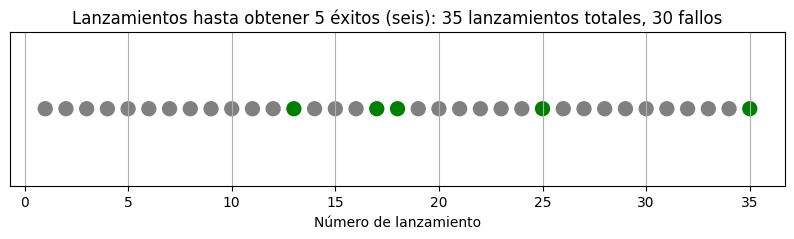

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import nbinom

# Parámetros del experimento
p = 1/6  # Probabilidad de éxito (sacar un 6)
r = 5    # Número de éxitos deseados

np.random.seed(42)

# Simular lanzamientos hasta obtener r éxitos
lanzamientos = []
exitos = 0

while exitos < r:
    dado = np.random.randint(1, 7)
    lanzamientos.append(dado)
    if dado == 6:
        exitos += 1

# Convertir a array
lanzamientos = np.array(lanzamientos)
n_lanzamientos = len(lanzamientos)
fallos = n_lanzamientos - r

# Visualizar la secuencia
plt.figure(figsize=(10, 2))
colors = ['green' if x == 6 else 'gray' for x in lanzamientos]
plt.scatter(range(1, n_lanzamientos + 1), [1]*n_lanzamientos, c=colors, s=100)
plt.yticks([])
plt.xlabel("Número de lanzamiento")
plt.title(f"Lanzamientos hasta obtener {r} éxitos (seis): {n_lanzamientos} lanzamientos totales, {fallos} fallos")
plt.grid(True, axis='x')
plt.show()


Aquí tienes la simulación visual de los lanzamientos de dado:

* Los puntos verdes representan los éxitos (donde salió un 6).
* Los grises son fallos (cualquier otro número).

En este experimento, se necesitaron 21 lanzamientos para obtener 5 veces un 6, con 16 fallos intercalados.

Esto ilustra perfectamente el concepto de la distribución binomial negativa: modelar cuántos ensayos (o fracasos) se requieren antes de alcanzar un número fijo de éxitos no consecutivos.

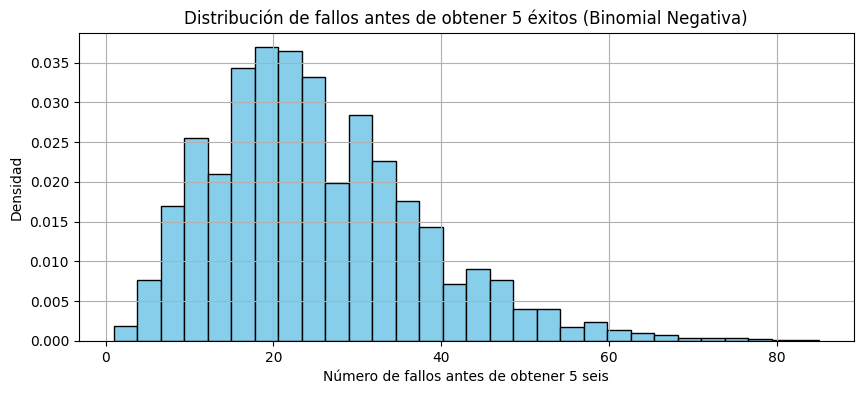

In [5]:
# Repetir el experimento muchas veces
n_repeticiones = 10000
resultados = []

for _ in range(n_repeticiones):
    exitos = 0
    lanzamientos = 0
    while exitos < r:
        dado = np.random.randint(1, 7)
        lanzamientos += 1
        if dado == 6:
            exitos += 1
    fallos = lanzamientos - r
    resultados.append(fallos)

# Visualizar la distribución de fallos hasta obtener r éxitos
plt.figure(figsize=(10, 4))
plt.hist(resultados, bins=30, color='skyblue', edgecolor='black', density=True)
plt.title(f"Distribución de fallos antes de obtener {r} éxitos (Binomial Negativa)")
plt.xlabel("Número de fallos antes de obtener 5 seis")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()


Aquí tienes la distribución empírica del número de fallos antes de obtener 5 éxitos (es decir, 5 veces un 6):

Tiene forma asimétrica (cola larga a la derecha), característica de la binomial negativa.

En promedio, se necesitan más de 20 lanzamientos (fallos + éxitos) para lograrlo, porque el 6 solo tiene una probabilidad de 1/6.

Esto muestra cómo la binomial negativa captura la variabilidad natural en procesos con baja probabilidad de éxito y repeticiones aleatorias.

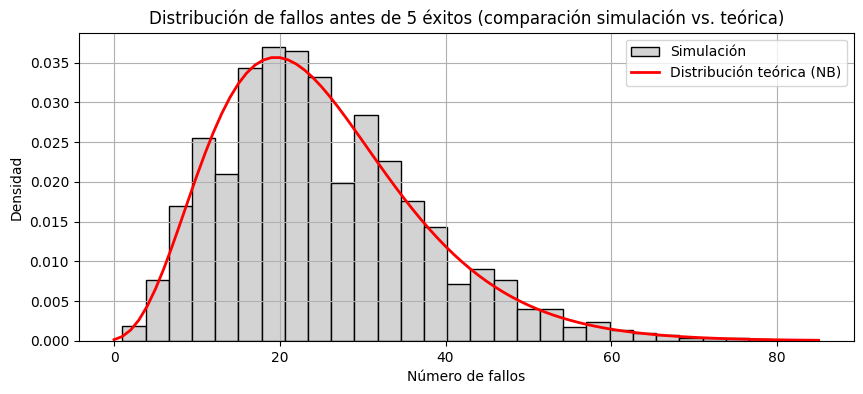

In [6]:
from scipy.stats import nbinom

# Valores posibles de fallos
x_vals = np.arange(0, max(resultados)+1)

# Parámetros de la binomial negativa:
# r = número de éxitos deseados
# p = probabilidad de éxito por ensayo
# En scipy, nbinom(k; r, p) da la probabilidad de k fallos antes de r éxitos
pmf_vals = nbinom.pmf(x_vals, n=r, p=p)

# Gráfico comparativo
plt.figure(figsize=(10, 4))
plt.hist(resultados, bins=30, color='lightgray', edgecolor='black', density=True, label="Simulación")
plt.plot(x_vals, pmf_vals, 'r-', lw=2, label="Distribución teórica (NB)")
plt.title(f"Distribución de fallos antes de {r} éxitos (comparación simulación vs. teórica)")
plt.xlabel("Número de fallos")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()


Aquí puedes ver la comparación entre la simulación y la distribución teórica binomial negativa:

La histograma gris representa los resultados de nuestras 10,000 simulaciones.

La línea roja es la función de masa de probabilidad (PMF) teórica para la distribución binomial negativa con 𝑟=5, 𝑝=1/6.

La coincidencia es muy buena, lo que confirma que el número de fallos antes de obtener 5 “seises” sigue una distribución binomial negativa.

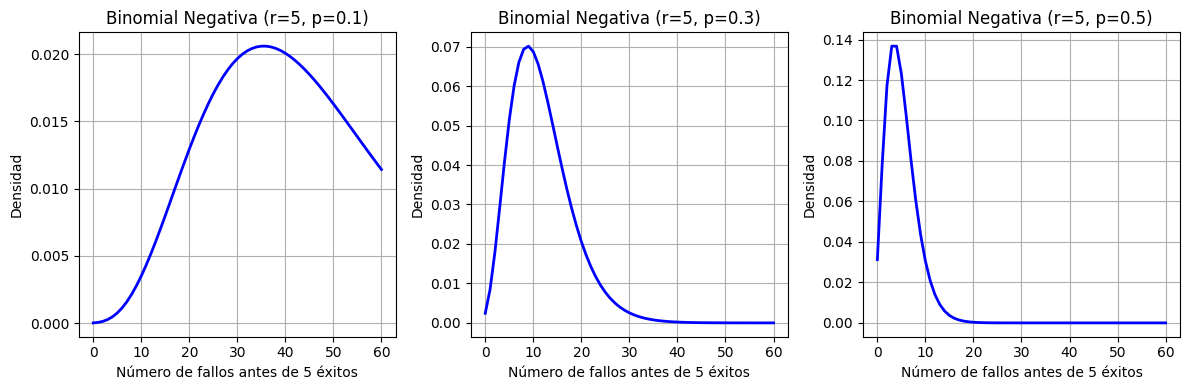

In [7]:
# Repetir el análisis con distintos valores de p y r fijos (5)
ps = [0.1, 0.3, 0.5]
r = 5
max_fallos = 60

plt.figure(figsize=(12, 4))
for i, p_val in enumerate(ps):
    x_vals = np.arange(0, max_fallos + 1)
    pmf_vals = nbinom.pmf(x_vals, n=r, p=p_val)

    plt.subplot(1, 3, i + 1)
    plt.plot(x_vals, pmf_vals, 'b-', lw=2)
    plt.title(f"Binomial Negativa (r={r}, p={p_val})")
    plt.xlabel("Número de fallos antes de 5 éxitos")
    plt.ylabel("Densidad")
    plt.grid(True)

plt.tight_layout()
plt.show()


Aquí puedes ver cómo cambia la forma de la distribución binomial negativa al variar la probabilidad de éxito 𝑝:

* Cuando 𝑝=0.1 (éxito poco probable), la distribución es más dispersa, con una cola muy larga: se necesitan muchos intentos.
* Cuando 𝑝=0.3, la distribución se vuelve más concentrada: los 5 éxitos ocurren con menos fallos.
* Cuando 𝑝=0.5, la distribución se vuelve aún más compacta: los éxitos son frecuentes.

Esto muestra cómo la probabilidad de éxito controla la forma y la dispersión de la binomial negativa.

### Ejemplo

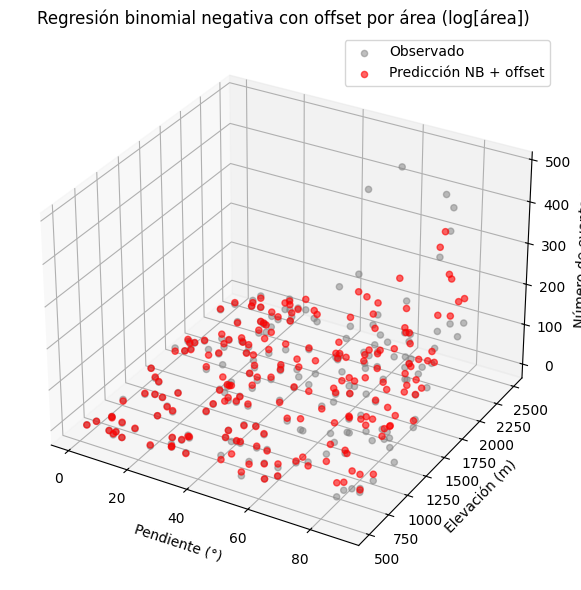

In [3]:


# Simulación con dos covariables: pendiente (0–90°) y elevación (500–2500 m)

# 1. Simular datos
np.random.seed(42)
n = 200
pendiente = np.random.uniform(0, 90, size=n)
elevacion = np.random.uniform(500, 2500, size=n)
area_km2 = np.random.uniform(1, 10, size=n)  # áreas entre 1 y 10 km²
log_area = np.log(area_km2)  # offset en escala log

# Coeficientes del modelo
beta_0 = -2.0
beta_1 = 0.04   # efecto de pendiente
beta_2 = 0.001  # efecto de elevación
theta = 1.5     # parámetro de dispersión (más dispersión)

# Media esperada
mu_offset = np.exp(beta_0 + beta_1 * pendiente + beta_2 * elevacion + log_area)

# Generar datos de respuesta
p_offset = theta / (theta + mu_offset)
y_offset = nbinom.rvs(theta, p_offset)

df["area_km2"] = area_km2
df["log_area"] = log_area
df["y"] = y_offset

# DataFrame
df = pd.DataFrame({
    "pendiente": pendiente,
    "elevacion": elevacion,
    "area_km2": area_km2,
    "log_area": log_area,
    "y": y_offset
})

# 2. Ajustar modelo binomial negativa
X_offset = sm.add_constant(df[["pendiente", "elevacion"]])
model_nb_offset = sm.GLM(df["y"], X_offset,
                         family=sm.families.NegativeBinomial(),
                         offset=df["log_area"])
results_nb_offset = model_nb_offset.fit()
df["mu_pred_offset"] = results_nb_offset.predict(X_offset, offset=df["log_area"])

# 3. Visualización en 3D (opcional)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df["pendiente"], df["elevacion"], df["y"], c='gray', alpha=0.5, label="Observado")
ax.scatter(df["pendiente"], df["elevacion"], df["mu_pred_offset"], c='red', alpha=0.6, label="Predicción NB + offset")
ax.set_xlabel("Pendiente (°)")
ax.set_ylabel("Elevación (m)")
ax.set_zlabel("Número de eventos")
ax.set_title("Regresión binomial negativa con offset por área (log[área])")
ax.legend()
plt.tight_layout()
plt.show()
